In [ ]:
# Устанавливаем необходимые библиотеки для курсового проекта.
# kaggle — нужен для скачивания датасета с Kaggle.
# shap — нужен для интерпретации модели и объяснения предсказаний.
# xgboost и lightgbm — дополнительные библиотеки градиентного бустинга, оставлены для возможного расширения работы.
!pip install kaggle shap xgboost lightgbm -q


In [ ]:
# Импортируем модуль files из Google Colab.
# Он позволяет загрузить локальный файл с компьютера прямо в среду Colab.
from google.colab import files

# Загружаем файл kaggle.json.
# В этом файле находится токен доступа к Kaggle API.
# Содержимое файла нельзя публиковать, потому что это личный ключ аккаунта Kaggle.
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"platonich","key":"a2486a21e845eb04f72622511749780e"}'}

In [ ]:
# os нужен для работы с папками, путями и правами доступа.
# shutil нужен для копирования файла kaggle.json в нужную системную папку.
import os
import shutil

# Создаем папку, в которой Kaggle API ищет файл авторизации.
# exist_ok=True означает, что ошибки не будет, если папка уже существует.
os.makedirs('/root/.kaggle', exist_ok=True)

# Копируем загруженный kaggle.json в папку /root/.kaggle.
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')

# Устанавливаем права доступа 600, чтобы файл был доступен только владельцу.
# Без этого Kaggle может выдать предупреждение или ошибку безопасности.
os.chmod('/root/.kaggle/kaggle.json', 600)

# Выводим сообщение, чтобы убедиться, что настройка прошла успешно.
print("Kaggle API настроен успешно")


Kaggle API настроен успешно


In [ ]:
# Создаем папку /content/data, куда будет скачан датасет.
os.makedirs('/content/data', exist_ok=True)

# Скачиваем датасет Ethereum Fraud Detection с Kaggle.
# Ключ -d указывает идентификатор датасета, а -p — папку для сохранения.
!kaggle datasets download -d vagifa/ethereum-frauddetection-dataset -p /content/data

# Распаковываем скачанный zip-архив в папку /content/data.
# Ключ -o разрешает перезаписать файлы, если они уже были распакованы ранее.
!unzip -o /content/data/ethereum-frauddetection-dataset.zip -d /content/data

# Показываем список файлов в папке, чтобы проверить, что CSV-файл появился.
!ls -lah /content/data


Dataset URL: https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset
License(s): DbCL-1.0
100% 923k/923k [00:00<00:00, 105MB/s]

Archive:  /content/data/ethereum-frauddetection-dataset.zip
  inflating: /content/data/transaction_dataset.csv  
total 3.7M
drwxr-xr-x 2 root root 4.0K May 18 07:46 .
drwxr-xr-x 1 root root 4.0K May 18 07:46 ..
-rw-r--r-- 1 root root 923K Jan  3  2021 ethereum-frauddetection-dataset.zip
-rw-r--r-- 1 root root 2.8M Jan  3  2021 transaction_dataset.csv


In [ ]:
# Импортируем pandas — основную библиотеку для работы с табличными данными.
import pandas as pd

# Загружаем CSV-файл с датасетом в DataFrame df.
df = pd.read_csv('/content/data/transaction_dataset.csv')

# Выводим размер датасета: количество строк и количество столбцов.
print("Размер датасета:", df.shape)

# Показываем первые 5 строк, чтобы визуально проверить структуру данных.
df.head()


Размер датасета: (9841, 51)


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [ ]:
# df.info() показывает общую информацию о датасете:
# количество строк, названия столбцов, количество непустых значений и типы данных.
# Это помогает понять, какие признаки числовые, какие текстовые, и где могут быть пропуски.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

In [ ]:
# Выводим список всех столбцов датасета.
# Это нужно, чтобы понять, какие признаки есть в данных и какие из них потом использовать для модели.
df.columns


Index(['Unnamed: 0', 'Index', 'Address', 'FLAG', 'Avg min between sent tnx',
       'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'min value sent to contract', 'max val sent to contract',
       'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq sent addr.1', ' ERC20 uniq rec contract addr',
       ' ERC20 avg time between sent tnx', ' ERC20 

In [ ]:
# Считаем количество пропущенных значений в каждом столбце.
# isnull() находит пропуски, sum() считает их количество, sort_values() сортирует по убыванию.
missing_values = df.isnull().sum().sort_values(ascending=False)

# Выводим только те столбцы, где количество пропусков больше нуля.
# Так удобнее увидеть проблемные признаки.
missing_values[missing_values > 0]


,0
ERC20 most sent token type,2697
ERC20_most_rec_token_type,871
ERC20 avg val sent,829
ERC20 total Ether received,829
ERC20 total ether sent,829
ERC20 avg time between rec tnx,829
ERC20 avg time between rec 2 tnx,829
ERC20 max val rec,829
ERC20 avg val rec,829
ERC20 avg time between contract tnx,829


In [ ]:
# Смотрим распределение целевого признака FLAG.
# FLAG = 0 означает нормальный объект, FLAG = 1 означает мошеннический/подозрительный объект.
df['FLAG'].value_counts()


,count
FLAG,
0,7662
1,2179


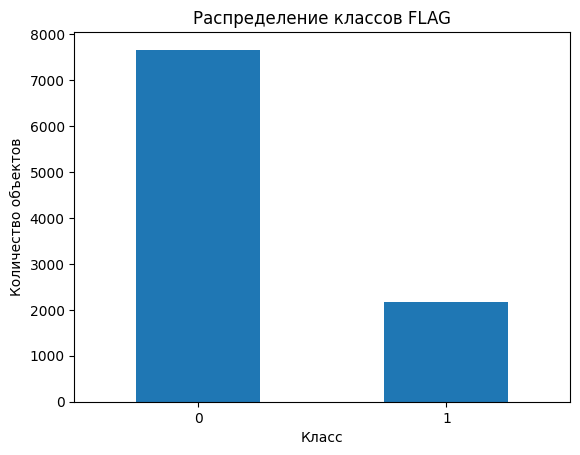

In [ ]:
# Импортируем matplotlib для построения графиков.
import matplotlib.pyplot as plt

# Строим столбчатую диаграмму распределения классов целевого признака FLAG.
df['FLAG'].value_counts().plot(kind='bar')

# Добавляем заголовок и подписи осей, чтобы график был понятен в отчете.
plt.title('Распределение классов FLAG')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)

# Показываем график.
plt.show()


In [ ]:
# Повторно проверяем пропуски перед очисткой данных.
# Этот блок фиксирует, какие признаки требуют обработки перед обучением модели.
missing_values = df.isnull().sum().sort_values(ascending=False)

# Отображаем только столбцы с пропущенными значениями.
missing_values[missing_values > 0]


,0
ERC20 most sent token type,2697
ERC20_most_rec_token_type,871
ERC20 avg val sent,829
ERC20 total Ether received,829
ERC20 total ether sent,829
ERC20 avg time between rec tnx,829
ERC20 avg time between rec 2 tnx,829
ERC20 max val rec,829
ERC20 avg val rec,829
ERC20 avg time between contract tnx,829


In [ ]:
# Создаем копию исходного датасета, чтобы не изменять df напрямую.
# Все дальнейшие преобразования будут выполняться в df_clean.
df_clean = df.copy()

# Убираем случайные пробелы в названиях столбцов.
# Это снижает риск ошибок при обращении к признакам по имени.
df_clean.columns = df_clean.columns.str.strip()

# Перечисляем столбцы, которые не будем использовать в базовой модели:
# Unnamed: 0 и Index — технические индексы;
# Address — адрес кошелька, он является идентификатором, а не полезным числовым признаком;
# token type — текстовые признаки, которые на данном этапе исключаются для стабильного обучения.
columns_to_drop = [
    'Unnamed: 0',
    'Index',
    'Address',
    'ERC20 most sent token type',
    'ERC20_most_rec_token_type'
]

# Удаляем лишние столбцы.
# errors='ignore' нужен, чтобы код не падал, если какого-то столбца нет или он называется иначе.
df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')

# Проверяем новый размер датасета после удаления лишних признаков.
print("Размер датасета после удаления лишних столбцов:", df_clean.shape)

# Показываем первые строки очищенного датасета.
df_clean.head()


Размер датасета после удаления лишних столбцов: (9841, 46)


,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,...,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name
0,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,...,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0
1,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,...,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0
2,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,...,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0
3,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,...,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0
4,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,...,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0


In [ ]:
# Проверяем, остались ли в датасете текстовые столбцы типа object.
# Для большинства моделей sklearn признаки должны быть числовыми.
df_clean.select_dtypes(include='object').columns


Index([], dtype='object')

In [ ]:
# Заполняем пропущенные значения медианой по каждому числовому столбцу.
# Медиана выбрана потому, что она устойчивее к выбросам, чем среднее значение.
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

# Проверяем, остались ли пропуски после обработки.
# Если результат равен 0, значит датасет готов к дальнейшему анализу и обучению.
print("Количество пропусков после обработки:", df_clean.isnull().sum().sum())


Количество пропусков после обработки: 0


In [ ]:
# Получаем статистическое описание числовых признаков:
# count — количество значений, mean — среднее, std — стандартное отклонение,
# min/max — минимальное и максимальное значение, 25/50/75% — квартили.
# .T транспонирует таблицу, чтобы признаки были строками и таблицу было удобнее читать.
df_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
FLAG,9841.0,2.214206e-01,4.152241e-01,0.00,0.000000,0.000000e+00,0.000000,1.000000e+00
Avg min between sent tnx,9841.0,5.086879e+03,2.148655e+04,0.00,0.000000,1.734000e+01,565.470000,4.302877e+05
Avg min between received tnx,9841.0,8.004851e+03,2.308171e+04,0.00,0.000000,5.097700e+02,5480.390000,4.821755e+05
Time Diff between first and last (Mins),9841.0,2.183333e+05,3.229379e+05,0.00,316.930000,4.663703e+04,304070.980000,1.954861e+06
Sent tnx,9841.0,1.159317e+02,7.572264e+02,0.00,1.000000,3.000000e+00,11.000000,1.000000e+04
Received Tnx,9841.0,1.637009e+02,9.408366e+02,0.00,1.000000,4.000000e+00,27.000000,1.000000e+04
Number of Created Contracts,9841.0,3.729702e+00,1.414456e+02,0.00,0.000000,0.000000e+00,0.000000,9.995000e+03
Unique Received From Addresses,9841.0,3.036094e+01,2.986211e+02,0.00,1.000000,2.000000e+00,5.000000,9.999000e+03
Unique Sent To Addresses,9841.0,2.584016e+01,2.638204e+02,0.00,1.000000,2.000000e+00,3.000000,9.287000e+03
min value received,9841.0,4.384515e+01,3.259291e+02,0.00,0.001000,9.585600e-02,2.000000,1.000000e+04


In [ ]:
# Считаем количество объектов каждого класса целевой переменной FLAG.
class_counts = df_clean['FLAG'].value_counts()

# Считаем процентное соотношение классов.
# Это важно, чтобы оценить баланс классов в задаче fraud detection.
class_percent = df_clean['FLAG'].value_counts(normalize=True) * 100

# Объединяем количество и процент в одну таблицу для отчета.
class_distribution = pd.DataFrame({
    'Количество': class_counts,
    'Процент': class_percent.round(2)
})

# Показываем итоговую таблицу распределения классов.
class_distribution


,Количество,Процент
FLAG,,
0,7662,77.86
1,2179,22.14


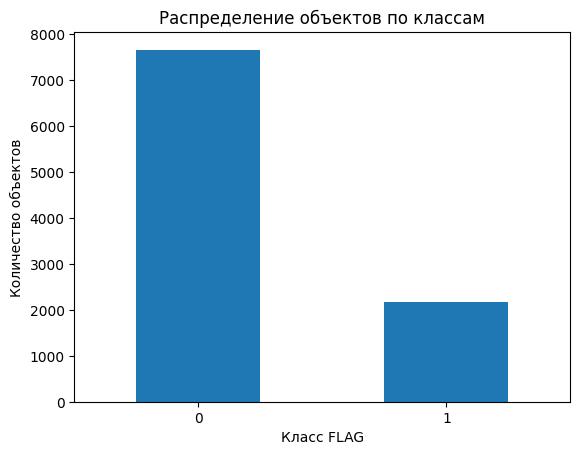

In [ ]:
# Импортируем matplotlib для построения графика.
import matplotlib.pyplot as plt

# Строим столбчатый график по количеству объектов каждого класса.
class_distribution['Количество'].plot(kind='bar')

# Добавляем заголовок и подписи осей.
plt.title('Распределение объектов по классам')
plt.xlabel('Класс FLAG')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)

# Показываем график.
plt.show()


In [ ]:
# Считаем корреляцию всех числовых признаков с целевым признаком FLAG.
# Корреляция показывает линейную связь признака с классом fraud/non-fraud.
correlation_with_target = df_clean.corr(numeric_only=True)['FLAG'].sort_values(ascending=False)

# Выводим список признаков, отсортированный по корреляции с FLAG.
correlation_with_target


,FLAG
FLAG,1.000000
ERC20 min val sent,0.019023
ERC20 avg val sent,0.018835
ERC20 max val sent,0.018770
ERC20 total ether sent,0.018428
ERC20 total Ether sent contract,0.008127
min val sent,0.006626
ERC20 min val rec,0.004434
ERC20 avg val rec,0.003132
total ether balance,-0.003229


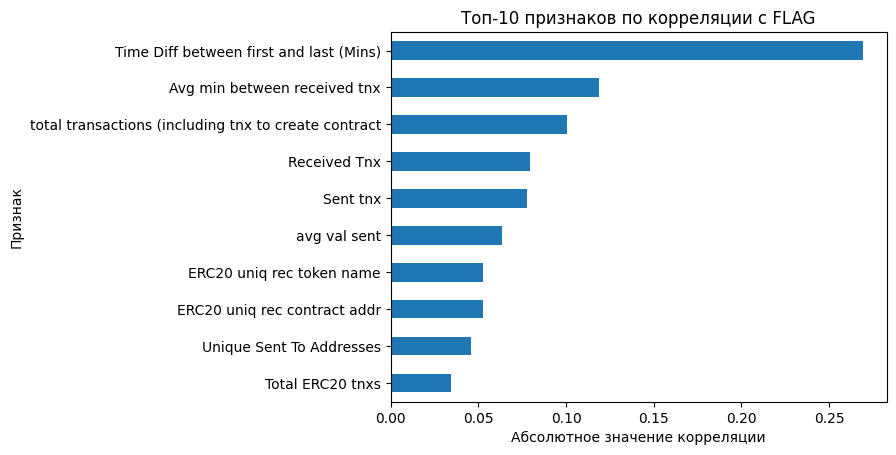

In [ ]:
# Берем 10 признаков с наибольшей абсолютной корреляцией с целевой переменной.
# abs() нужен, потому что сильная отрицательная связь тоже может быть важной.
top_corr = correlation_with_target.drop('FLAG').abs().sort_values(ascending=False).head(10)

# Строим горизонтальную диаграмму топ-10 коррелирующих признаков.
top_corr.plot(kind='barh')

# Добавляем оформление графика.
plt.title('Топ-10 признаков по корреляции с FLAG')
plt.xlabel('Абсолютное значение корреляции')
plt.ylabel('Признак')
plt.gca().invert_yaxis()
plt.show()


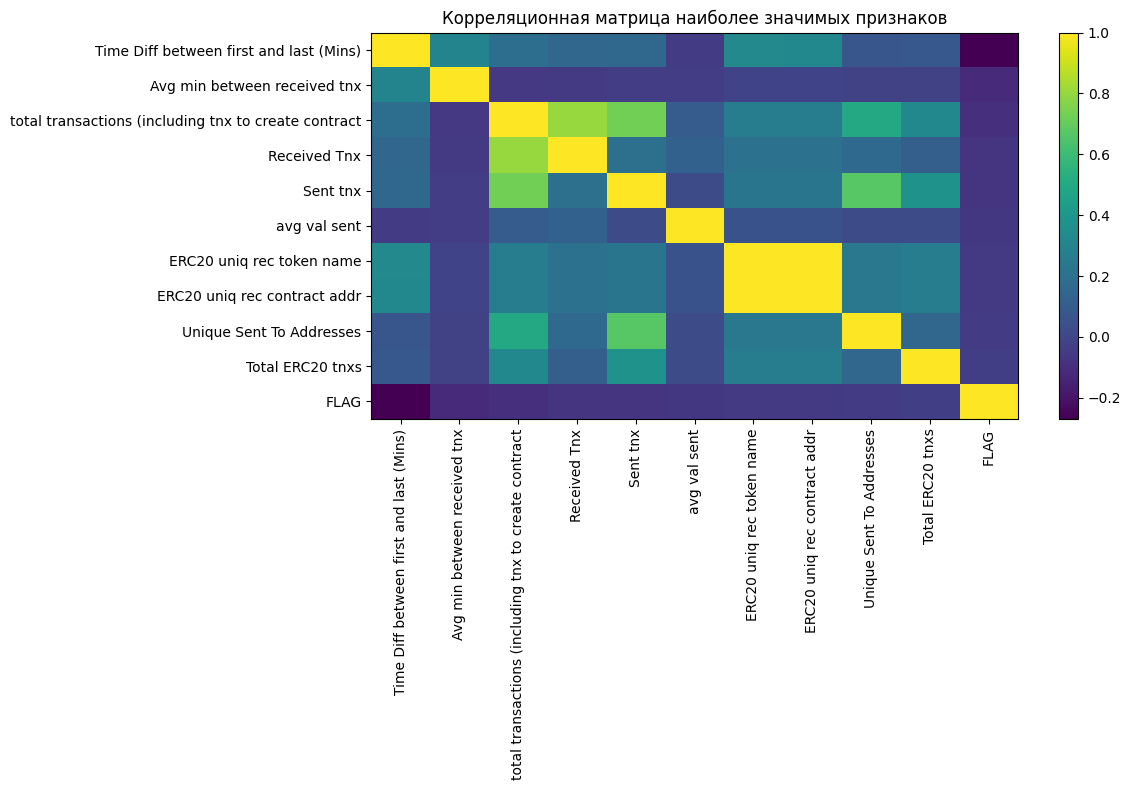

In [ ]:
# Импортируем matplotlib для построения корреляционной матрицы.
import matplotlib.pyplot as plt

# Выбираем признаки из топа корреляций и добавляем целевой признак FLAG.
top_features = top_corr.index.tolist() + ['FLAG']

# Строим корреляционную матрицу для выбранных признаков.
# Она показывает взаимосвязи между признаками и помогает увидеть похожие/связанные признаки.
corr_matrix = df_clean[top_features].corr(numeric_only=True)

# Создаем изображение корреляционной матрицы.
plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Корреляционная матрица наиболее значимых признаков')
plt.tight_layout()
plt.show()


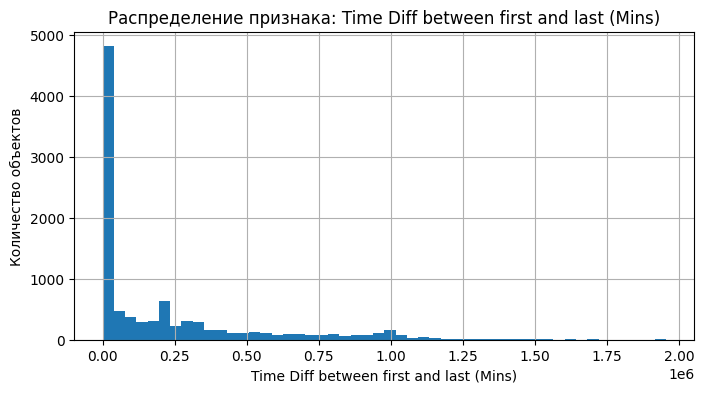

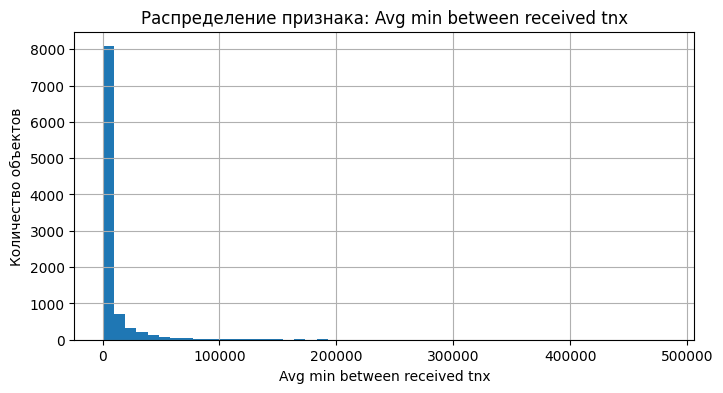

KeyError: 'total transactions (including tnx to create contract)'

<Figure size 800x400 with 0 Axes>

In [ ]:
# Ищем все столбцы, в названии которых есть слово transactions.
# Это нужно, потому что в датасете один столбец имеет нестандартное название без закрывающей скобки.
[col for col in df_clean.columns if 'transaction' in col.lower()]


In [ ]:
# Формируем список ключевых признаков, по которым построим гистограммы распределения.
# Гистограммы позволяют увидеть, как распределены значения признаков и есть ли сильная асимметрия.
features_to_plot = [
    'Time Diff between first and last (Mins)',
    'Avg min between received tnx',
    'total transactions (including tnx to create contract',
    'Received Tnx',
    'Sent tnx'
]

# Для каждого выбранного признака строим отдельную гистограмму.
for feature in features_to_plot:
    plt.figure(figsize=(8, 4))
    df_clean[feature].hist(bins=50)
    plt.title(f'Распределение признака: {feature}')
    plt.xlabel(feature)
    plt.ylabel('Количество объектов')
    plt.show()


['total transactions (including tnx to create contract']

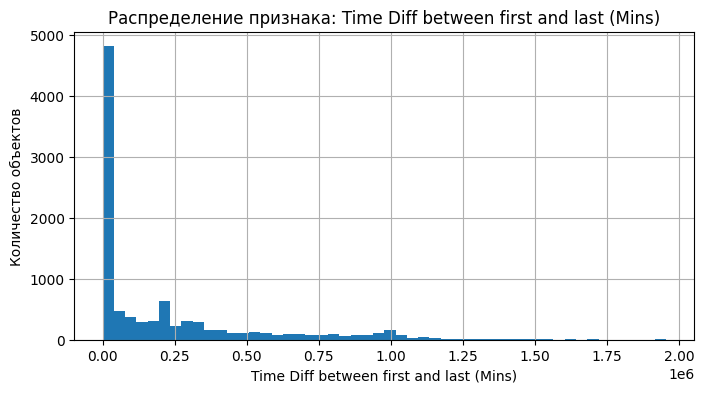

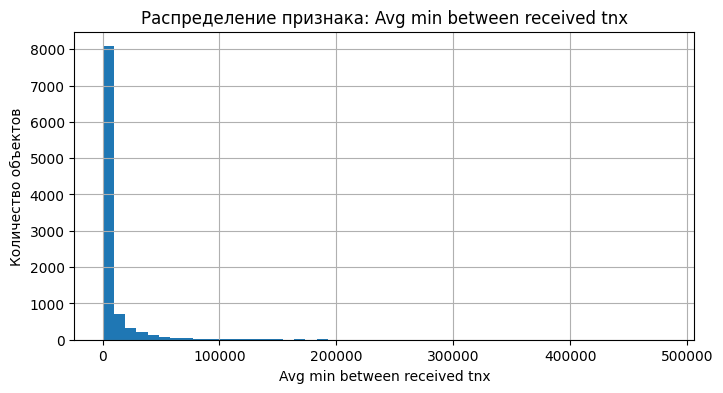

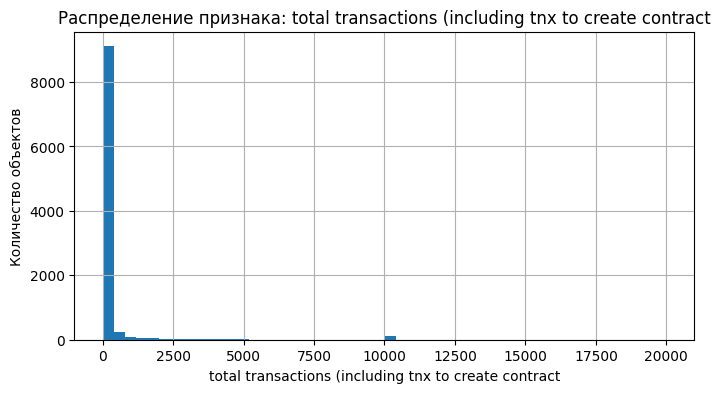

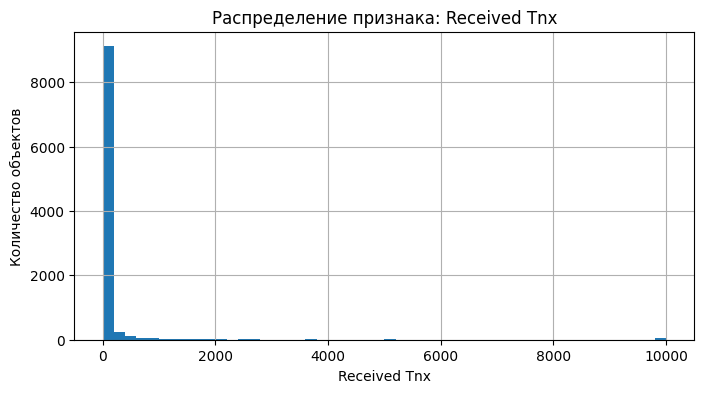

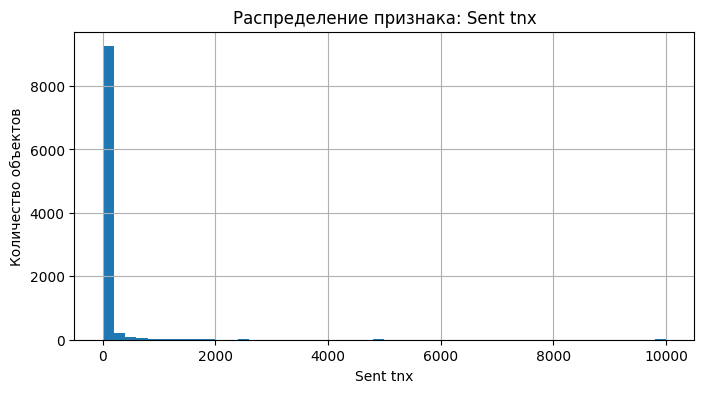

In [ ]:
# Строим boxplot-графики для выбранных признаков.
# Boxplot помогает увидеть медиану, разброс значений и выбросы.
# В криптовалютных данных выбросы ожидаемы, потому что отдельные адреса могут иметь очень высокую активность.
for feature in features_to_plot:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_clean[feature], vert=False)
    plt.title(f'Boxplot признака: {feature}')
    plt.xlabel(feature)
    plt.show()


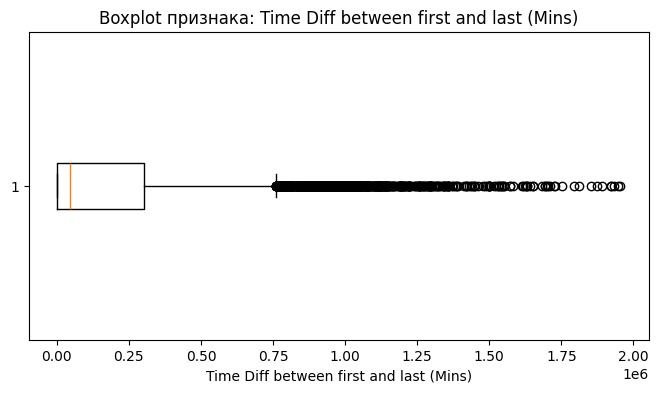

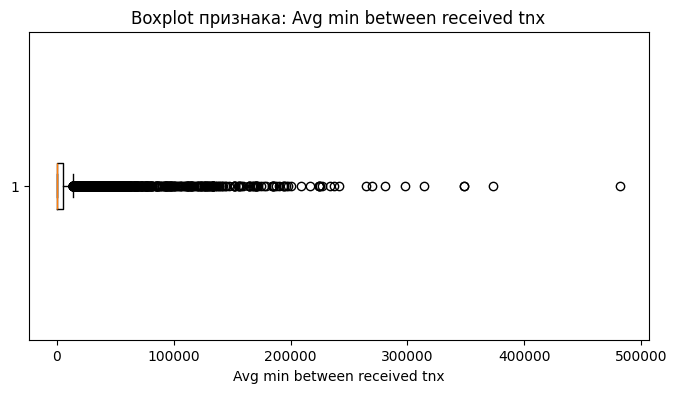

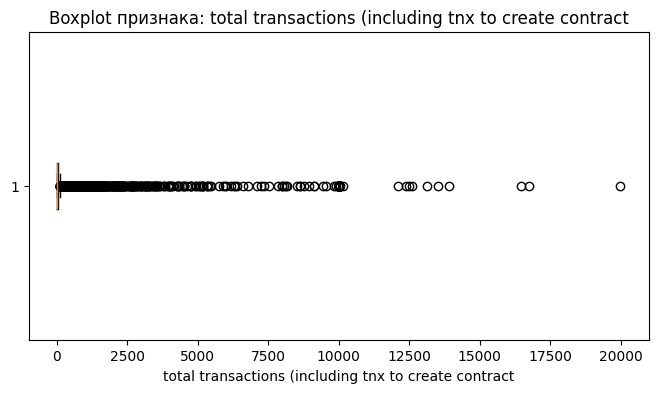

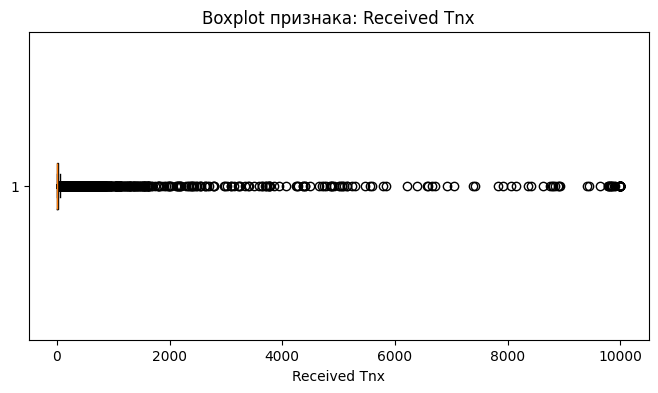

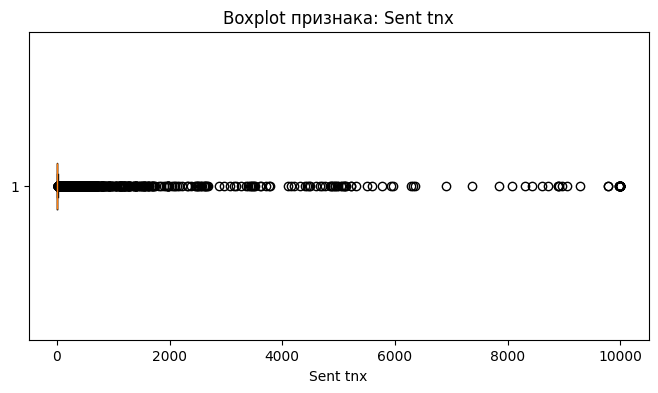

In [ ]:
# Проверяем список признаков, которые использовались для гистограмм и boxplot.
# Этот список пригодится для описания этапа анализа данных в отчете.
features_to_plot


In [ ]:
# Разделяем данные на признаки X и целевую переменную y.
# X содержит все входные признаки, по которым модель будет делать прогноз.
# y содержит правильные ответы — класс FLAG.
X = df_clean.drop('FLAG', axis=1)
y = df_clean['FLAG']

# Проверяем размеры X и y.
print("Размер X:", X.shape)
print("Размер y:", y.shape)


Размер X: (9841, 45)
Размер y: (9841,)


In [ ]:
# Импортируем функцию для разделения данных на обучающую и тестовую выборки.
from sklearn.model_selection import train_test_split

# Делим датасет на train и test.
# test_size=0.2 означает, что 20% данных оставляем для тестирования.
# random_state=42 фиксирует случайность, чтобы результат можно было повторить.
# stratify=y сохраняет одинаковое соотношение классов fraud/non-fraud в train и test.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Выводим размеры обучающей и тестовой выборок.
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

# Проверяем распределение классов в обучающей выборке.
print("
Распределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True).round(3))

# Проверяем распределение классов в тестовой выборке.
print("
Распределение классов в тестовой выборке:")
print(y_test.value_counts(normalize=True).round(3))


Размер обучающей выборки: (7872, 45)
Размер тестовой выборки: (1969, 45)

Распределение классов в обучающей выборке:
FLAG
0    0.779
1    0.221
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
FLAG
0    0.779
1    0.221
Name: proportion, dtype: float64


In [ ]:
# Импортируем StandardScaler для масштабирования признаков.
# Масштабирование нужно для моделей, чувствительных к масштабу признаков: Logistic Regression и KNN.
from sklearn.preprocessing import StandardScaler

# Создаем объект scaler.
scaler = StandardScaler()

# fit_transform обучает scaler на обучающей выборке и сразу преобразует X_train.
X_train_scaled = scaler.fit_transform(X_train)

# transform применяет уже обученный scaler к тестовой выборке.
# Важно: на тесте fit делать нельзя, чтобы не было утечки данных.
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено")


Масштабирование выполнено


In [ ]:
# Импортируем алгоритмы машинного обучения для классификации.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Импортируем метрики качества модели.
# Accuracy — общая доля правильных ответов.
# Precision — точность определения fraud среди всех объектов, предсказанных как fraud.
# Recall — полнота, то есть доля найденных fraud-объектов.
# F1-score — баланс между Precision и Recall.
# ROC-AUC — способность модели разделять два класса на разных порогах.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Создаем словарь моделей, которые будем сравнивать.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Создаем пустой список, куда будем сохранять результаты каждой модели.
results = []

# Последовательно обучаем каждую модель и считаем метрики.
for name, model in models.items():
    # Logistic Regression и KNN чувствительны к масштабу признаков,
    # поэтому для них используем X_train_scaled и X_test_scaled.
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Если модель умеет выдавать вероятности, берем вероятность класса 1 для ROC-AUC.
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_proba = y_pred
    else:
        # Деревья и бустинг не требуют обязательного масштабирования,
        # поэтому обучаем их на исходных числовых признаках.
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = y_pred

    # Сохраняем метрики текущей модели в список results.
    results.append({
        "Модель": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

# Превращаем список результатов в таблицу DataFrame.
results_df = pd.DataFrame(results)

# Выводим таблицу сравнения моделей.
results_df


,Модель,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.772473,0.300000,0.020642,0.038627,0.841888
1,Decision Tree,0.969528,0.943396,0.917431,0.930233,0.950888
2,Random Forest,0.980701,0.980676,0.931193,0.955294,0.997320
3,Gradient Boosting,0.981209,0.987775,0.926606,0.956213,0.997289
4,KNN,0.948197,0.907317,0.853211,0.879433,0.960388


In [ ]:
# Сортируем таблицу моделей по F1-score по убыванию.
# F1-score важен для fraud detection, потому что учитывает и точность, и полноту.
results_df.sort_values(by="F1-score", ascending=False)


,Модель,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Gradient Boosting,0.981209,0.987775,0.926606,0.956213,0.997289
2,Random Forest,0.980701,0.980676,0.931193,0.955294,0.997320
1,Decision Tree,0.969528,0.943396,0.917431,0.930233,0.950888
4,KNN,0.948197,0.907317,0.853211,0.879433,0.960388
0,Logistic Regression,0.772473,0.300000,0.020642,0.038627,0.841888


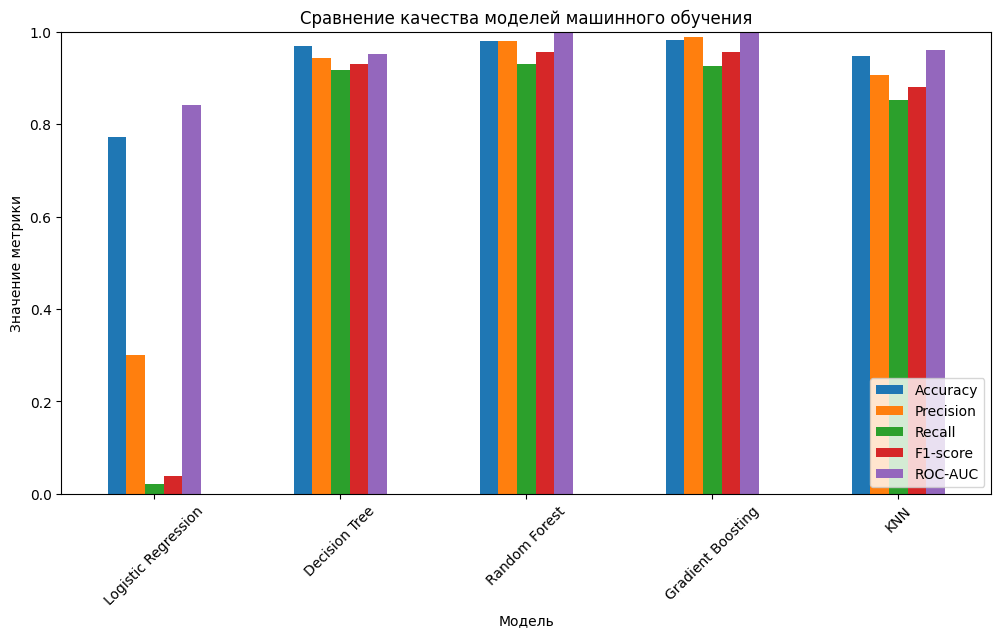

In [ ]:
# Строим столбчатый график сравнения моделей по основным метрикам.
# Это позволяет наглядно увидеть, какая модель показала лучший результат.
results_df.set_index("Модель")[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(12, 6)
)

# Оформляем график для отчета.
plt.title("Сравнение качества моделей машинного обучения")
plt.ylabel("Значение метрики")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()


In [ ]:
# Еще раз выводим отсортированную таблицу, чтобы зафиксировать лучшую модель.
# По результатам сравнения лучшей моделью является Gradient Boosting.
results_df.sort_values(by="F1-score", ascending=False)


,Модель,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Gradient Boosting,0.981209,0.987775,0.926606,0.956213,0.997289
2,Random Forest,0.980701,0.980676,0.931193,0.955294,0.997320
1,Decision Tree,0.969528,0.943396,0.917431,0.930233,0.950888
4,KNN,0.948197,0.907317,0.853211,0.879433,0.960388
0,Logistic Regression,0.772473,0.300000,0.020642,0.038627,0.841888


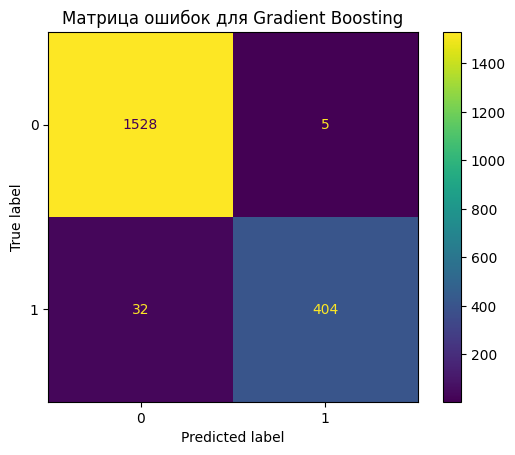

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1533
           1       0.99      0.93      0.96       436

    accuracy                           0.98      1969
   macro avg       0.98      0.96      0.97      1969
weighted avg       0.98      0.98      0.98      1969



In [ ]:
# Импортируем инструменты для подробной оценки модели:
# confusion_matrix — матрица ошибок;
# ConfusionMatrixDisplay — визуализация матрицы ошибок;
# classification_report — отчет с Precision, Recall и F1-score по каждому классу.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Создаем лучшую базовую модель Gradient Boosting.
best_model = GradientBoostingClassifier(random_state=42)

# Обучаем модель на обучающей выборке.
best_model.fit(X_train, y_train)

# Получаем предсказанные классы на тестовой выборке.
y_pred_best = best_model.predict(X_test)

# Получаем вероятности класса 1 для расчета ROC-AUC и ROC-кривой.
y_proba_best = best_model.predict_proba(X_test)[:, 1]

# Считаем матрицу ошибок.
cm = confusion_matrix(y_test, y_pred_best)

# Визуализируем матрицу ошибок.
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Матрица ошибок для Gradient Boosting")
plt.show()

# Выводим подробный отчет классификации по классам 0 и 1.
print(classification_report(y_test, y_pred_best))


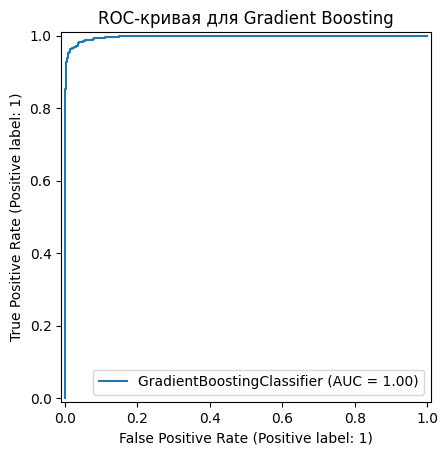

In [ ]:
# Импортируем инструмент для построения ROC-кривой.
from sklearn.metrics import RocCurveDisplay

# Строим ROC-кривую для лучшей модели Gradient Boosting.
# ROC-кривая показывает зависимость True Positive Rate от False Positive Rate.
RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title("ROC-кривая для Gradient Boosting")
plt.show()


In [ ]:
# Импортируем GridSearchCV для подбора гиперпараметров модели.
from sklearn.model_selection import GridSearchCV

# Задаем сетку гиперпараметров для Gradient Boosting.
# n_estimators — количество деревьев;
# learning_rate — скорость обучения;
# max_depth — максимальная глубина дерева;
# min_samples_split — минимальное число объектов для разбиения узла.
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5]
}

# Создаем GridSearchCV.
# scoring='f1' означает, что лучшая модель выбирается по F1-score.
# cv=3 — используется трехкратная кросс-валидация.
# n_jobs=-1 — задействуются все доступные ядра процессора.
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Запускаем перебор параметров и обучение моделей на обучающей выборке.
grid_search.fit(X_train, y_train)

# Выводим лучшие найденные параметры.
print("Лучшие параметры:")
print(grid_search.best_params_)

# Выводим лучший F1-score на кросс-валидации.
print("
Лучший F1-score на кросс-валидации:")
print(grid_search.best_score_)


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Лучшие параметры:
{'learning_rate': 0.2, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 150}

Лучший F1-score на кросс-валидации:
0.9689714356005572


In [ ]:
# Извлекаем лучшую модель, найденную GridSearchCV.
best_grid_model = grid_search.best_estimator_

# Делаем предсказания классов на тестовой выборке.
y_pred_grid = best_grid_model.predict(X_test)

# Получаем вероятности класса 1 для ROC-AUC.
y_proba_grid = best_grid_model.predict_proba(X_test)[:, 1]

# Выводим метрики качества после подбора гиперпараметров.
print("Метрики модели после GridSearch:")
print("Accuracy:", accuracy_score(y_test, y_pred_grid))
print("Precision:", precision_score(y_test, y_pred_grid))
print("Recall:", recall_score(y_test, y_pred_grid))
print("F1-score:", f1_score(y_test, y_pred_grid))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_grid))

# Выводим подробный classification report для оптимизированной модели.
print("
Classification Report:")
print(classification_report(y_test, y_pred_grid))


Метрики модели после GridSearch:
Accuracy: 0.983748095479939
Precision: 0.9879227053140096
Recall: 0.9380733944954128
F1-score: 0.9623529411764706
ROC-AUC: 0.9974655439654811

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1533
           1       0.99      0.94      0.96       436

    accuracy                           0.98      1969
   macro avg       0.99      0.97      0.98      1969
weighted avg       0.98      0.98      0.98      1969



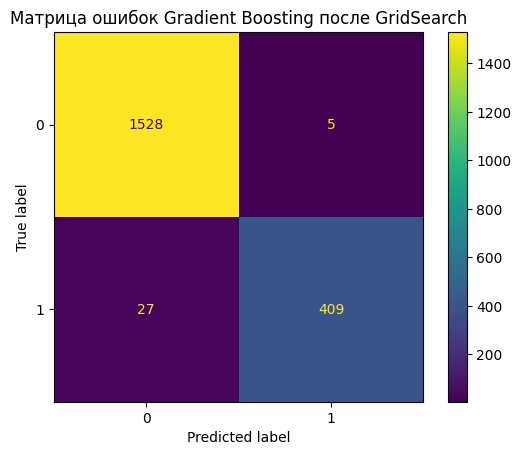

In [ ]:
# Считаем матрицу ошибок для модели после GridSearch.
cm_grid = confusion_matrix(y_test, y_pred_grid)

# Визуализируем матрицу ошибок.
disp = ConfusionMatrixDisplay(confusion_matrix=cm_grid)
disp.plot()

plt.title("Матрица ошибок Gradient Boosting после GridSearch")
plt.show()


In [ ]:
# Импортируем pandas и matplotlib на случай, если ячейка запускается отдельно.
import pandas as pd
import matplotlib.pyplot as plt

# Создаем таблицу важности признаков для оптимизированной модели Gradient Boosting.
# feature_importances_ показывает, насколько сильно каждый признак участвовал в построении модели.
feature_importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': best_grid_model.feature_importances_
}).sort_values(by='Важность', ascending=False)

# Выводим 15 самых важных признаков.
feature_importance.head(15)


,Признак,Важность
2,Time Diff between first and last (Mins),0.368289
22,Total ERC20 tnxs,0.215111
9,max value received,0.082043
34,ERC20 min val rec,0.068777
6,Unique Received From Addresses,0.044321
23,ERC20 total Ether received,0.042847
19,total ether received,0.031378
11,min val sent,0.021063
17,total transactions (including tnx to create co...,0.018156
35,ERC20 max val rec,0.017436


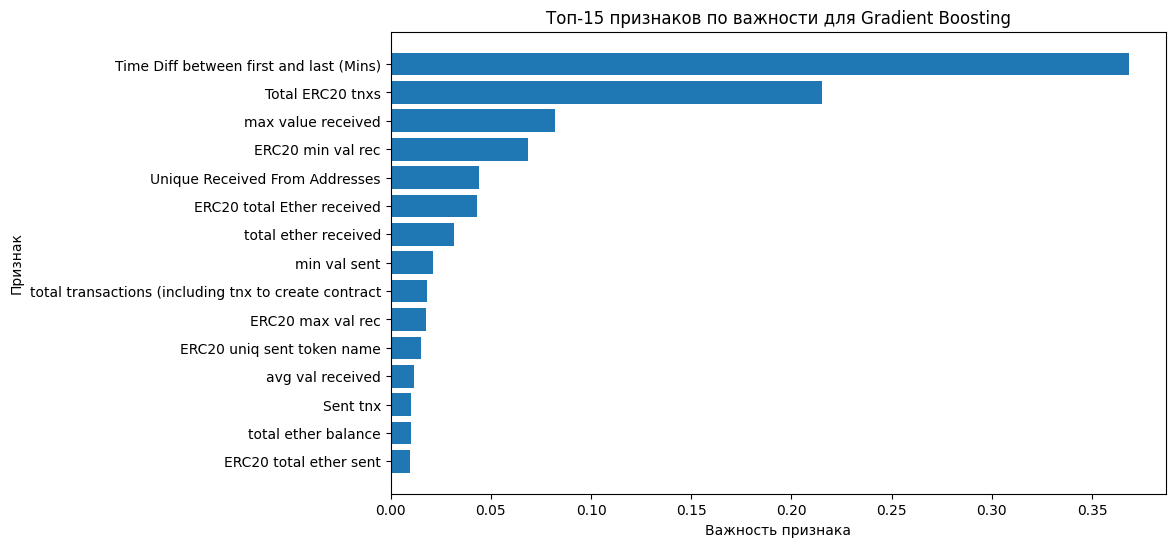

In [ ]:
# Берем топ-15 признаков по важности.
top_features_importance = feature_importance.head(15)

# Строим горизонтальный график важности признаков.
plt.figure(figsize=(10, 6))
plt.barh(top_features_importance['Признак'], top_features_importance['Важность'])
plt.gca().invert_yaxis()
plt.title('Топ-15 признаков по важности для Gradient Boosting')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.show()


In [ ]:
# Импортируем библиотеку SHAP.
# SHAP используется для интерпретации модели: он показывает вклад каждого признака в предсказание.
import shap

# Инициализируем JavaScript-визуализации SHAP для Colab/Jupyter.
shap.initjs()


In [ ]:
# Для ускорения расчета SHAP берем не весь тестовый набор, а случайные 500 объектов.
X_test_sample = X_test.sample(n=500, random_state=42)

# Создаем SHAP-объяснитель для древовидной модели Gradient Boosting.
explainer = shap.TreeExplainer(best_grid_model)

# Рассчитываем SHAP-значения для выбранной части тестовой выборки.
# Эти значения показывают, как каждый признак влияет на предсказание модели.
shap_values = explainer.shap_values(X_test_sample)

print("SHAP-значения рассчитаны")


SHAP-значения рассчитаны


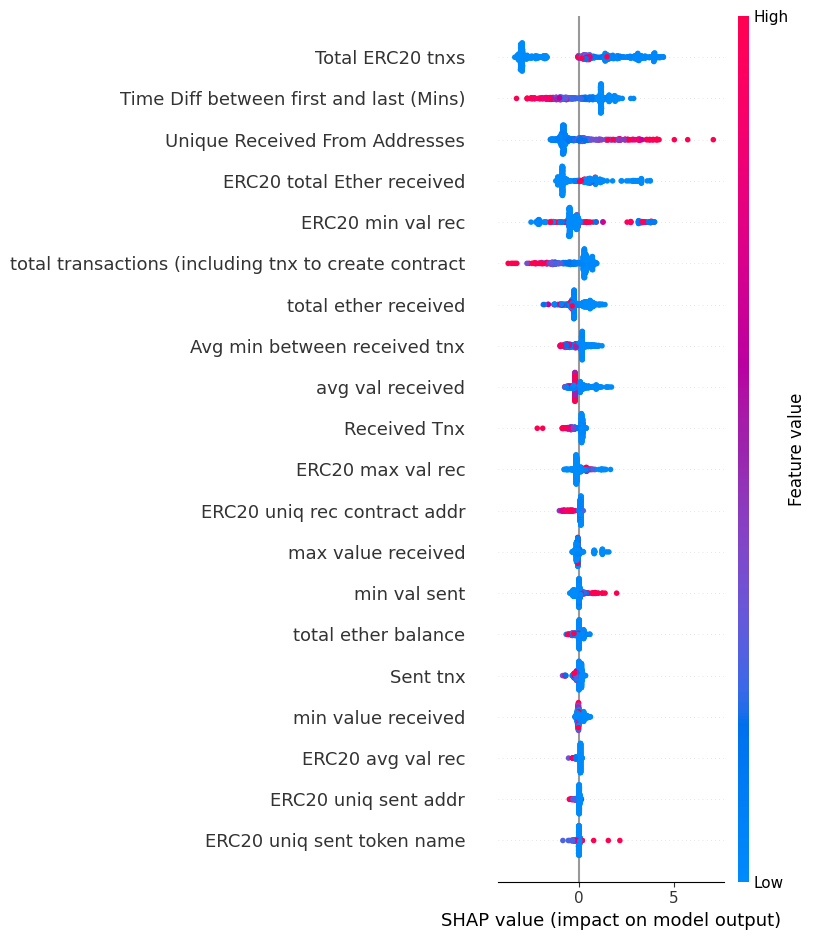

In [ ]:
# Строим SHAP summary plot.
# Он показывает, какие признаки сильнее всего влияют на модель,
# а также как высокие и низкие значения признаков двигают прогноз к классу fraud или non-fraud.
shap.summary_plot(shap_values, X_test_sample)


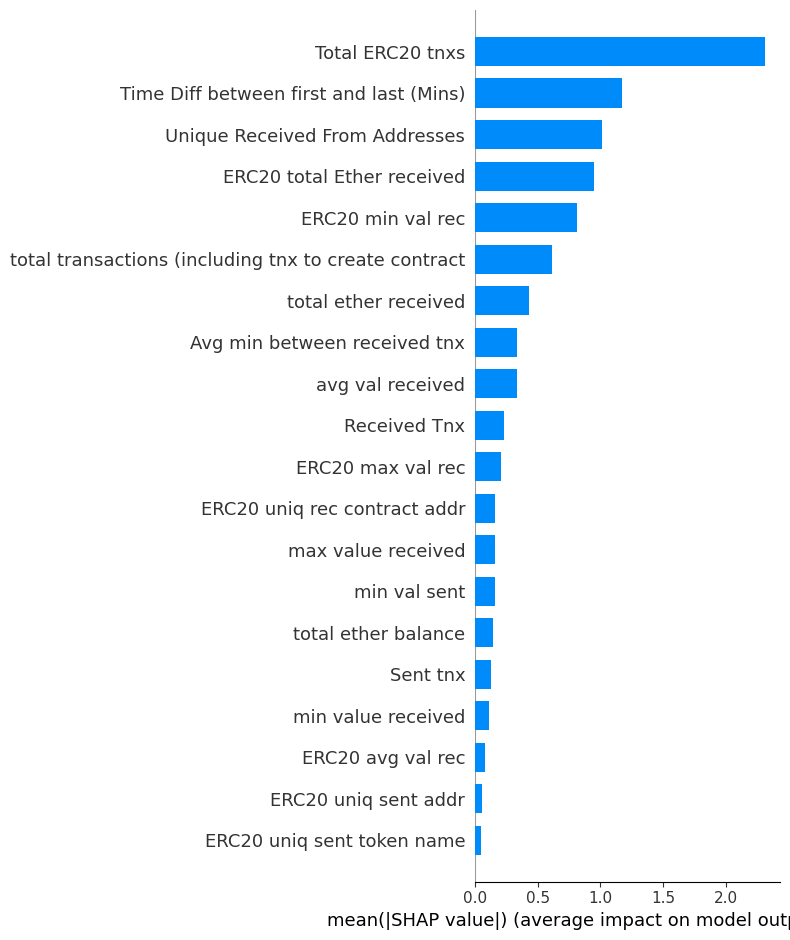

In [ ]:
# Строим SHAP bar plot.
# Этот график показывает среднюю абсолютную важность признаков по SHAP.
# Он удобен для краткого объяснения, какие признаки самые значимые.
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")


In [ ]:
# Находим индексы объектов из тестовой выборки, которые действительно относятся к классу fraud.
fraud_indices = y_test[y_test == 1].index

# Берем первый мошеннический объект для локальной интерпретации.
fraud_index = fraud_indices[0]

# Выводим индекс объекта, истинный класс, предсказанный класс и вероятность fraud.
# Это нужно, чтобы показать объяснение решения модели на конкретном примере.
print("Индекс выбранного мошеннического объекта:", fraud_index)
print("Истинный класс:", y_test.loc[fraud_index])
print("Предсказанный класс:", best_grid_model.predict(X_test.loc[[fraud_index]])[0])
print("Вероятность fraud:", best_grid_model.predict_proba(X_test.loc[[fraud_index]])[0][1])


Индекс выбранного мошеннического объекта: 9631
Истинный класс: 1
Предсказанный класс: 1
Вероятность fraud: 0.999463011191474


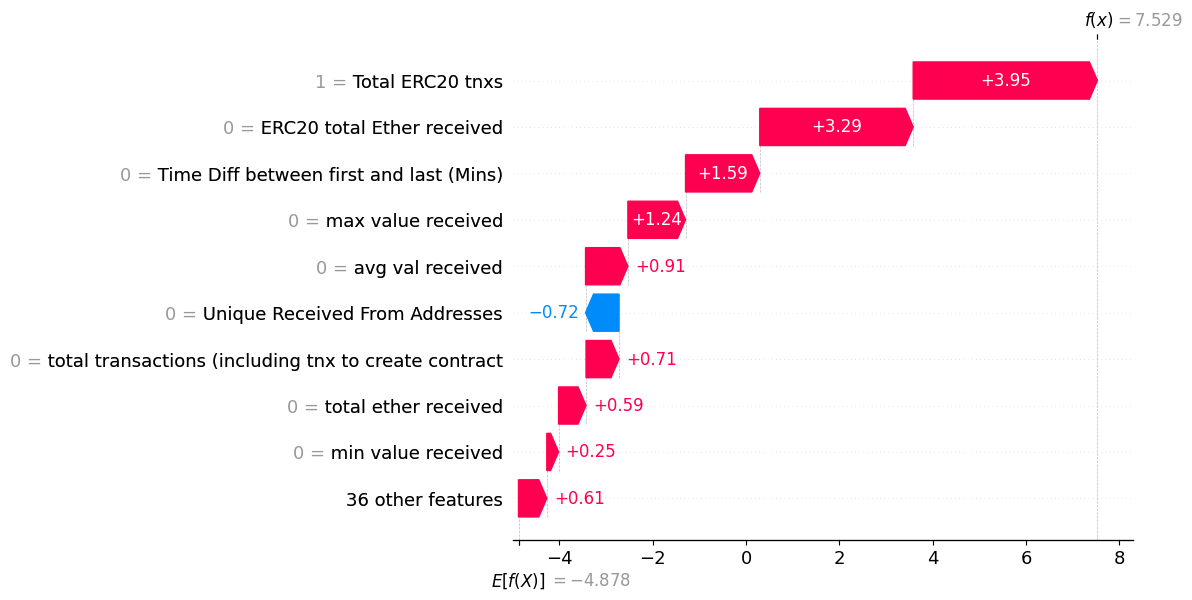

In [ ]:
# Выбираем один конкретный объект из тестовой выборки для объяснения.
single_object = X_test.loc[[fraud_index]]

# Создаем SHAP-объяснитель для оптимизированной модели.
explainer = shap.TreeExplainer(best_grid_model)

# Рассчитываем SHAP-значения для одного объекта.
single_shap_values = explainer(single_object)

# Строим waterfall plot.
# Он показывает, какие признаки повышают или понижают вероятность отнесения объекта к fraud.
shap.plots.waterfall(single_shap_values[0])


In [ ]:
# Задаем список наиболее важных признаков, значения которых хотим посмотреть у выбранного fraud-объекта.
important_features = [
    'Total ERC20 tnxs',
    'Time Diff between first and last (Mins)',
    'Unique Received From Addresses',
    'ERC20 total Ether received',
    'ERC20 min val rec',
    'total transactions (including tnx to create contract',
    'total ether received',
    'Avg min between received tnx',
    'Received Tnx',
    'Sent tnx'
]

# Выводим значения этих признаков для выбранного объекта.
# .T транспонирует таблицу, чтобы признаки были строками и их было удобнее читать.
X_test.loc[[fraud_index], important_features].T


,9631
Total ERC20 tnxs,1.000000e+00
Time Diff between first and last (Mins),0.000000e+00
Unique Received From Addresses,0.000000e+00
ERC20 total Ether received,1.000000e-12
ERC20 min val rec,0.000000e+00
total transactions (including tnx to create contract,0.000000e+00
total ether received,0.000000e+00
Avg min between received tnx,0.000000e+00
Received Tnx,0.000000e+00
Sent tnx,0.000000e+00


In [ ]:
# Создаем итоговую таблицу сравнения Gradient Boosting до и после GridSearch.
# Это показывает, дала ли настройка гиперпараметров улучшение качества модели.
final_comparison = pd.DataFrame({
    'Модель': ['Gradient Boosting до GridSearch', 'Gradient Boosting после GridSearch'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_grid)
    ],
    'Precision': [
        precision_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_grid)
    ],
    'Recall': [
        recall_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_grid)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_grid)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_best),
        roc_auc_score(y_test, y_proba_grid)
    ]
})

# Выводим итоговую таблицу.
final_comparison


,Модель,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting до GridSearch,0.981209,0.987775,0.926606,0.956213,0.997289
1,Gradient Boosting после GridSearch,0.983748,0.987923,0.938073,0.962353,0.997466


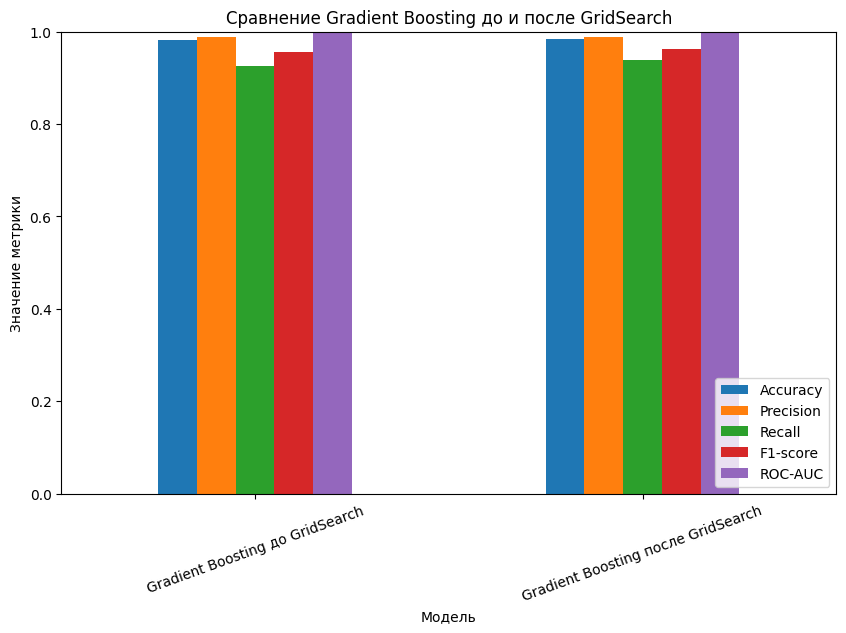

In [ ]:
# Строим график сравнения Gradient Boosting до и после настройки гиперпараметров.
final_comparison.set_index('Модель')[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(10, 6)
)

# Оформляем график для отчета.
plt.title('Сравнение Gradient Boosting до и после GridSearch')
plt.ylabel('Значение метрики')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()


In [ ]:
# Итоговый комментарий:
# На этом практическая часть завершена.
# В работе были выполнены загрузка данных, очистка, анализ, обучение нескольких моделей,
# подбор гиперпараметров лучшей модели и интерпретация результатов с помощью feature importance и SHAP.
print("Практическая часть курсового проекта завершена")


## Дополнительный анализ без учителя: Isolation Forest

В этом блоке применяется метод обучения без учителя для поиска аномальных объектов. 
Модель Isolation Forest обучается только на признаках `X` и не использует целевой признак `FLAG` при поиске аномалий. 
После этого результат сопоставляется с `FLAG`, чтобы оценить, насколько найденные аномалии пересекаются с мошенническими объектами.

In [ ]:
# Импортируем алгоритм Isolation Forest для поиска аномалий без учителя.
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt

# contamination задает ожидаемую долю аномалий.
# В качестве ориентировочной доли используем долю fraud-объектов в датасете.
contamination_rate = y.mean()

isolation_model = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=42
)

# Обучаем модель без использования FLAG.
# Алгоритм анализирует только структуру признаков и пытается найти нетипичные объекты.
isolation_pred = isolation_model.fit_predict(X)

# В Isolation Forest результат -1 означает аномалию, 1 означает нормальный объект.
# Преобразуем результат к виду 1 = аномалия, 0 = нормальный объект.
anomaly_flag = (isolation_pred == -1).astype(int)

# Сравниваем найденные аномалии с реальной меткой FLAG.
anomaly_comparison = pd.crosstab(
    y,
    anomaly_flag,
    rownames=['Реальный FLAG'],
    colnames=['Аномалия по Isolation Forest']
)

anomaly_comparison

In [ ]:
# Выводим отчет классификации, чтобы понять, насколько найденные аномалии совпадают с fraud-объектами.
print(classification_report(y, anomaly_flag))

# Строим график распределения найденных аномалий.
pd.Series(anomaly_flag).value_counts().sort_index().plot(kind='bar')
plt.title('Распределение объектов по результату Isolation Forest')
plt.xlabel('0 — нормальный объект, 1 — аномалия')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.show()